# Importing Libraries

In [53]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Phase 1
## Fetching Olivetti Data and Data Preperation

In [13]:
data_oliveti = fetch_olivetti_faces()

In [15]:
data_oliveti.data.shape

(400, 4096)

In [23]:
df = pd.DataFrame(data_oliveti.data)
df['target'] = data_oliveti.target
df.head(12)

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0
5,0.549587,0.545455,0.541322,0.537190,0.537190,0.533058,0.528926,0.533058,0.590909,0.611570,...,0.619835,0.623967,0.615702,0.661157,0.661157,0.690083,0.714876,0.706612,0.702479,0
6,0.330579,0.305785,0.330579,0.351240,0.425620,0.500000,0.603306,0.632231,0.644628,0.644628,...,0.541322,0.541322,0.524793,0.537190,0.487603,0.190083,0.144628,0.152893,0.152893,0
7,0.128099,0.185950,0.247934,0.314050,0.388430,0.462810,0.520661,0.557851,0.590909,0.623967,...,0.157025,0.165289,0.148760,0.157025,0.157025,0.152893,0.152893,0.173554,0.173554,0
8,0.243802,0.297521,0.367769,0.454545,0.495868,0.537190,0.578512,0.603306,0.611570,0.632231,...,0.669421,0.537190,0.235537,0.169421,0.177686,0.190083,0.190083,0.181818,0.190083,0
9,0.380165,0.442149,0.483471,0.545455,0.582645,0.628099,0.648760,0.677686,0.690083,0.710744,...,0.157025,0.165289,0.148760,0.165289,0.173554,0.173554,0.173554,0.173554,0.173554,0


## Dividing Datasets  into Train(%80) and Test(%20)
then we reshape it 

In [43]:
x = data_oliveti.data
y = data_oliveti.target

x_reshaped = x.reshape(40,10,4096)
y_reshaped = y.reshape(40,10)

x_train = x_reshaped[:,:8,:].reshape(320,4096)
x_test = x_reshaped[:,8:,:].reshape(80,4096)

y_train = y_reshaped[:,:8].reshape(320)
y_test = y_reshaped[:,8:].reshape(80)
print('x_train :',x_train.shape)
print('x_test : ',x_test.shape)
print('y_train : ',y_train.shape)
print('y_test : ',y_test.shape)

x_train : (320, 4096)
x_test :  (80, 4096)
y_train :  (320,)
y_test :  (80,)


## To Explore Some Data Visually

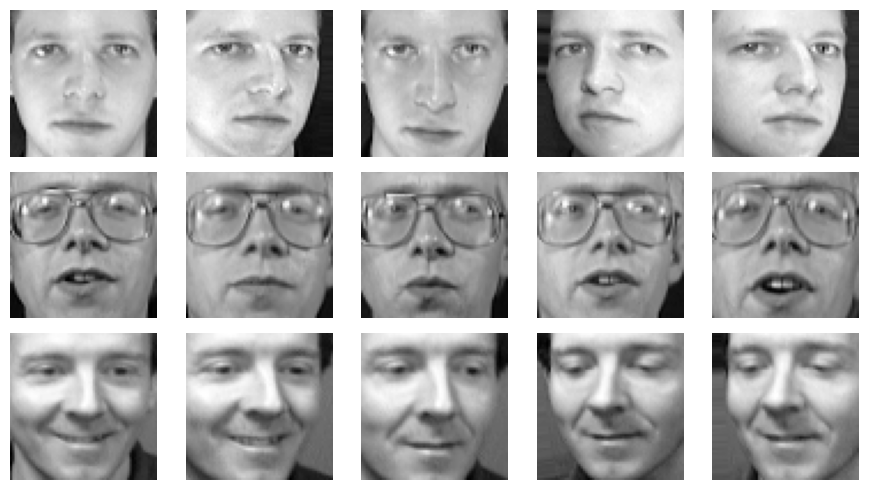

In [83]:
n_persons = 3
images_to_show = 5

fig, axes = plt.subplots(n_persons, images_to_show, figsize=(9, 5))

for person_idx in range(n_persons):
    for img_idx in range(images_to_show):
        # In X_train, each person has exactly 8 images. 
        # So Person 0 is indices 0-7, Person 1 is 8-15, etc.
        row_idx = (person_idx * 8) + img_idx
        
        # Grab the image vector and reshape to 64x64
        img = x_train[row_idx].reshape(64, 64)
        
        # Plot on the corresponding subplot
        ax = axes[person_idx, img_idx]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        
plt.tight_layout()
plt.show()

### Centering the data and plot the mean face

In [45]:
x_train_centered = x_train - np.mean(x_train, axis = 0)

Text(0.5, 1.0, 'Average Face')

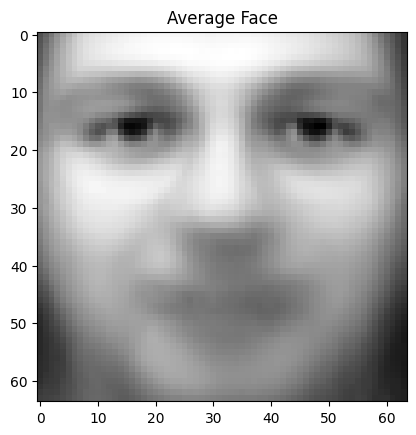

In [63]:
mean_face = np.mean(x_train, axis=0)
plt.imshow(mean_face.reshape(64, 64), cmap='gray')
plt.title("Average Face")

Text(0.5, 1.0, 'Average Face')

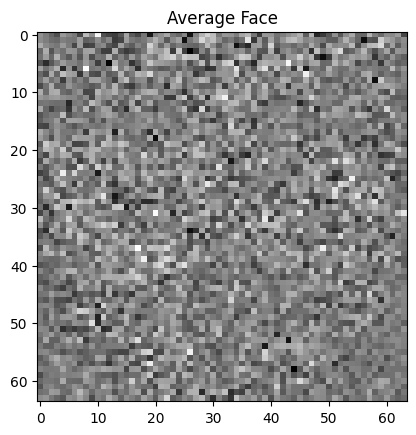

In [59]:
mean_face = np.mean(x_train_centered, axis=0)
plt.imshow(mean_face.reshape(64, 64), cmap='gray')
plt.title("Average Face")

In [47]:
x_train_centered.shape

(320, 4096)

# Building Covariance 

In [85]:
cov_matrix = np.cov(x_train_centered, rowvar = False)
print(cov_matrix.shape)
#cov_matrix = (1 / (X_train_centered.shape[0] - 1)) * (X_train_centered.T @ X_train_centered)

(4096, 4096)


# Build EigenVectors and EigenValues From Cov_Matrix


### then we sort the values to find how many of eigenvectors show the most variance

In [75]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print(f"Eigenvalues shape: {eigenvalues.shape}")
print(f"Eigenvectors shape: {eigenvectors.shape}")

Eigenvalues shape: (4096,)
Eigenvectors shape: (4096, 4096)


In [79]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
eigenvalues


array([ 1.85005578e+01,  1.01454846e+01,  6.28147103e+00, ...,
       -2.32023601e-15, -2.43002594e-15, -2.77260324e-15])

In [87]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)



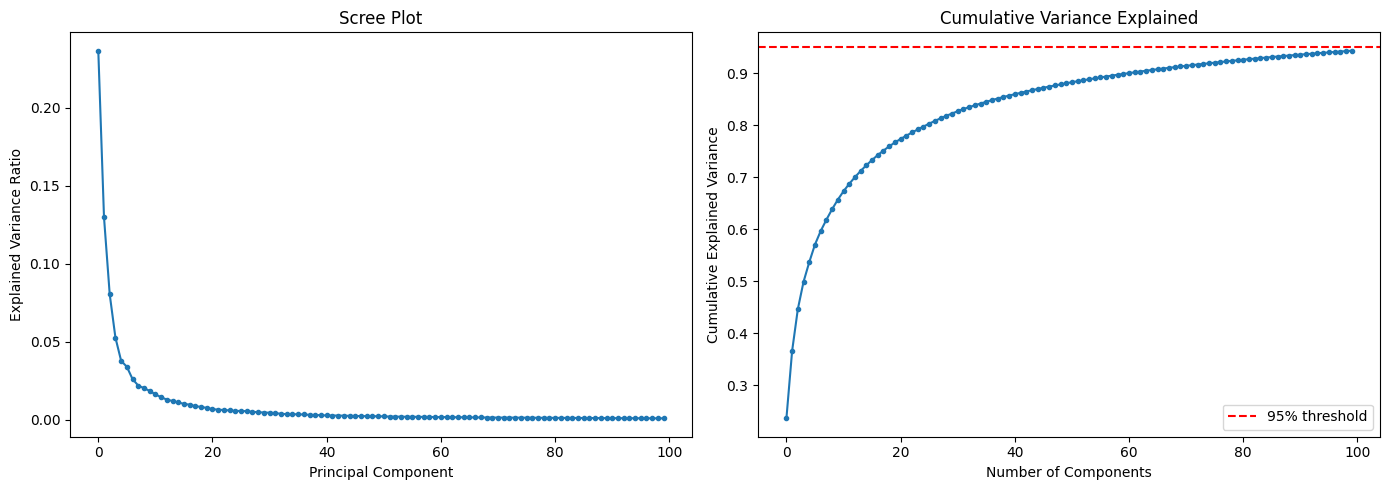

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot — individual variance per component
axes[0].plot(explained_variance_ratio[:100], marker='o', markersize=3)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

# Cumulative variance plot
axes[1].plot(cumulative_variance[:100], marker='o', markersize=3)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.tight_layout()
plt.show()

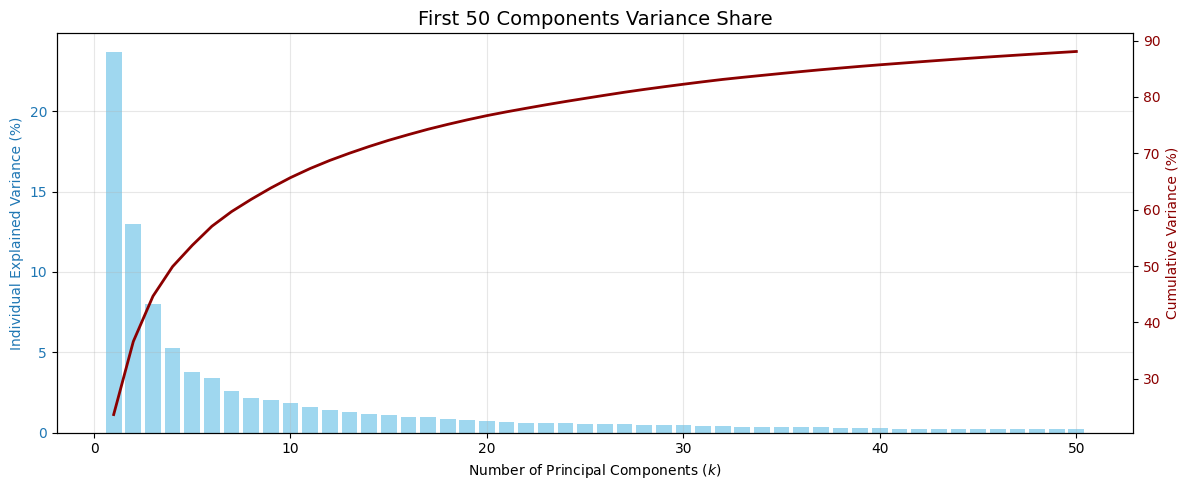

In [107]:
# 1. Calculate Explained Variance and Cumulative Variance
total_variance = np.sum(eigenvalues)
explained_variance_ratio = (eigenvalues / total_variance) * 100
cumulative_variance = np.cumsum(explained_variance_ratio)

# 2. Setup the single figure
fig, ax = plt.subplots(figsize=(12, 5))

# We only want to plot the first 50 components
k_50 = 50
x_50 = np.arange(1, k_50 + 1)

# Primary Y-axis: Bar plot for individual variance share
bars = ax.bar(x_50, explained_variance_ratio[:k_50], color='skyblue', alpha=0.8, label='Individual Variance Share')
ax.set_xlabel("Number of Principal Components ($k$)")
ax.set_ylabel("Individual Explained Variance (%)", color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')

# Secondary Y-axis: Line plot for cumulative variance
ax_twin = ax.twinx()
line = ax_twin.plot(x_50, cumulative_variance[:k_50], color='darkred', linewidth=2, label='Cumulative Variance')
ax_twin.set_ylabel("Cumulative Variance (%)", color='darkred')
ax_twin.tick_params(axis='y', labelcolor='darkred')

ax.set_title("First 50 Components Variance Share", fontsize=14, fontweight='normal')

# Combine legends from both axes into a single box
# lines_1, labels_1 = ax.get_legend_handles_labels()
# lines_2, labels_2 = ax_twin.get_legend_handles_labels()
# ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

# Add a subtle grid for easier reading
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ploting top 10 EigenFaces vs. some lower EigenFaces and compare the noise

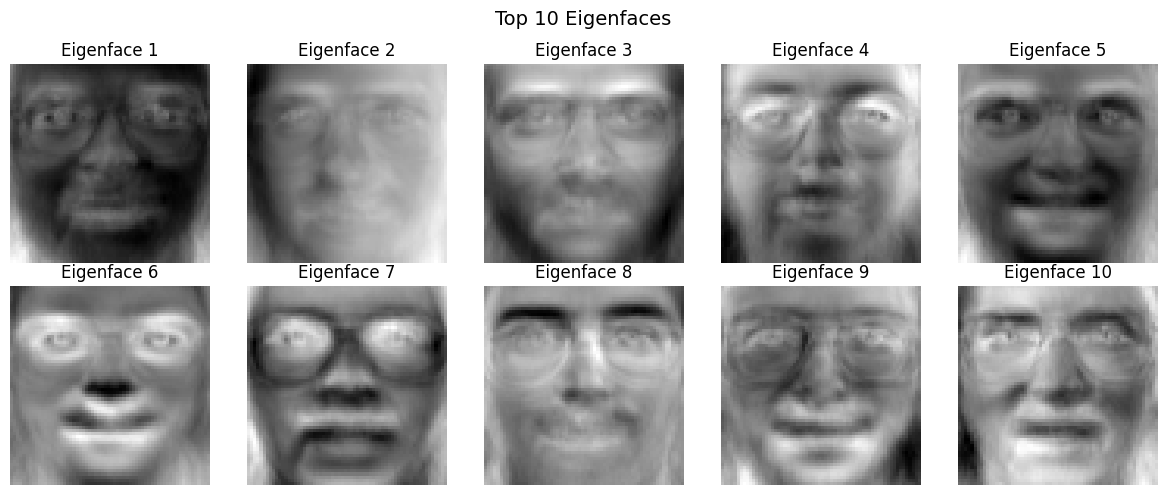

In [109]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    eigenface = eigenvectors[:, i].reshape(64, 64)
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')

plt.suptitle('Top 10 Eigenfaces', fontsize=14)
plt.tight_layout()
plt.show()

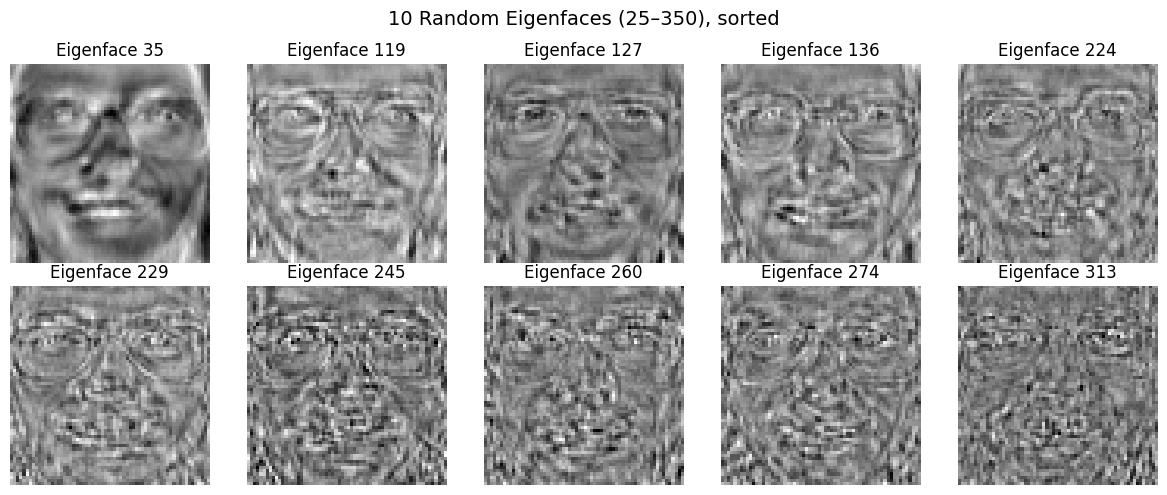

In [129]:
# Assuming eigenvectors/eigenvalues are already sorted descending
lower_bound = 25
upper_bound = 350

index_range = np.arange(lower_bound, upper_bound)

# Randomly sample 10 indices, then sort them in ascending order
np.random.seed(42)  # remove or change for different random picks each run
random_idx = np.random.choice(index_range, size=10, replace=False)
random_idx = np.sort(random_idx)   # put back in eigenface order

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, random_idx):
    eigenface = eigenvectors[:, idx].reshape(64, 64)
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'Eigenface {idx+1}')
    ax.axis('off')

plt.suptitle(f'10 Random Eigenfaces ({lower_bound}–{upper_bound}), sorted', fontsize=14)
plt.tight_layout()
plt.show()

### reconstructing 2 random sample from train samples 
### with K = 10 , 50 , 150 Principal Componenets

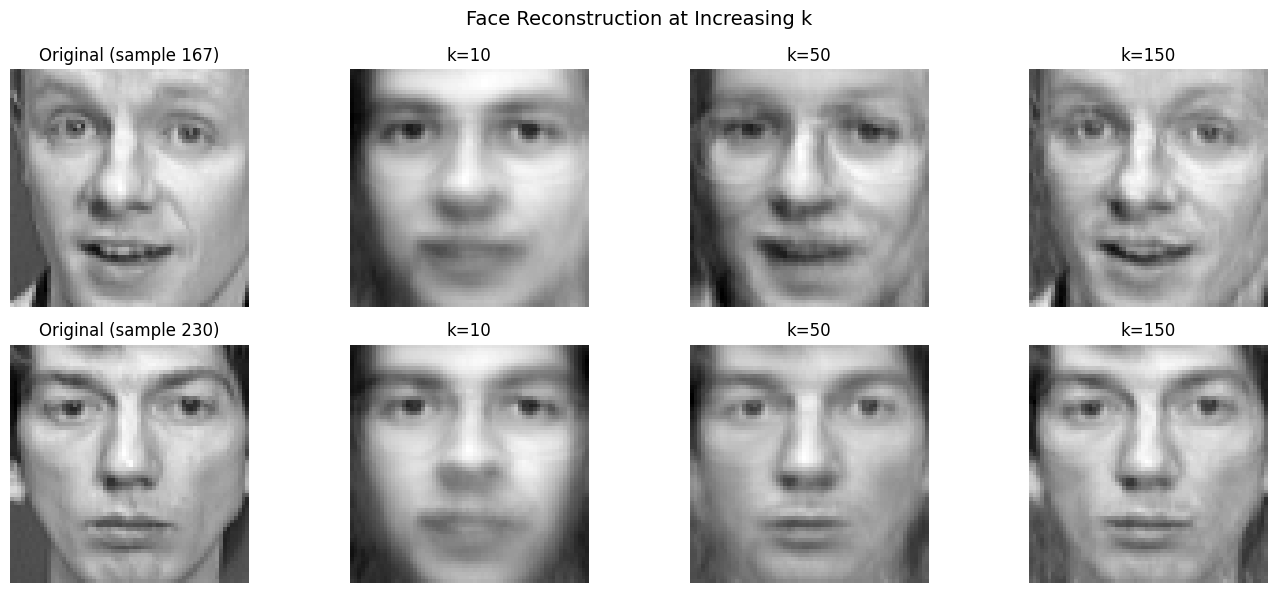

In [131]:
# Assuming eigenvectors is already sorted descending, and you have:
# x_train, x_train_centered, and mean_face = np.mean(x_train, axis=0)

mean_face = np.mean(x_train, axis=0)
k_values = [10, 50, 150]

# Pick 2 random sample indices from x_train
np.random.seed(42)  # remove or change for different random picks each run
sample_indices = np.random.choice(x_train.shape[0], size=2, replace=False)

fig, axes = plt.subplots(2, len(k_values) + 1, figsize=(14, 6))

for row, sample_idx in enumerate(sample_indices):
    face_centered = x_train_centered[sample_idx]

    # Original image (first column)
    axes[row, 0].imshow(x_train[sample_idx].reshape(64, 64), cmap='gray')
    axes[row, 0].set_title(f'Original (sample {sample_idx})')
    axes[row, 0].axis('off')

    # Reconstructions for each k, in order
    for col, k in enumerate(k_values, start=1):
        top_k_vecs = eigenvectors[:, :k]
        weights = face_centered @ top_k_vecs
        reconstructed = weights @ top_k_vecs.T + mean_face

        axes[row, col].imshow(reconstructed.reshape(64, 64), cmap='gray')
        axes[row, col].set_title(f'k={k}')
        axes[row, col].axis('off')

plt.suptitle('Face Reconstruction at Increasing k', fontsize=14)
plt.tight_layout()
plt.show()

In [147]:
mean_face = np.mean(x_train, axis=0)

def reconstruct(face_centered, eigenvectors, k, mean_face):
    top_k_vecs = eigenvectors[:, :k]
    weights = face_centered @ top_k_vecs
    reconstructed = weights @ top_k_vecs.T + mean_face
    return reconstructed

sample_idx = 0
k = 50

original = x_train[sample_idx]
face_centered = x_train_centered[sample_idx]
reconstructed = reconstruct(face_centered, eigenvectors, k, mean_face)

mse = np.mean((original - reconstructed) ** 2)
print(f"MSE (k={k}): {mse:.4f}")

MSE (k=50): 0.0021


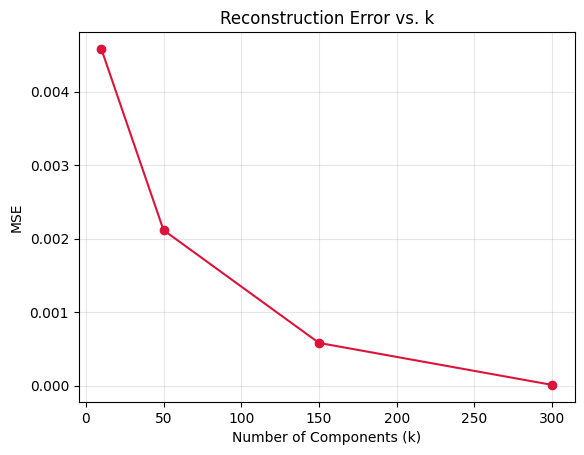

In [149]:
k_values = [10, 50, 150, 300]
mse_per_k = []

for k in k_values:
    reconstructed = reconstruct(face_centered, eigenvectors, k, mean_face)
    mse = np.mean((original - reconstructed) ** 2)
    mse_per_k.append(mse)

plt.plot(k_values, mse_per_k, marker='o', color='crimson')
plt.xlabel('Number of Components (k)')
plt.ylabel('MSE')
plt.title('Reconstruction Error vs. k')
plt.grid(alpha=0.3)
plt.show()

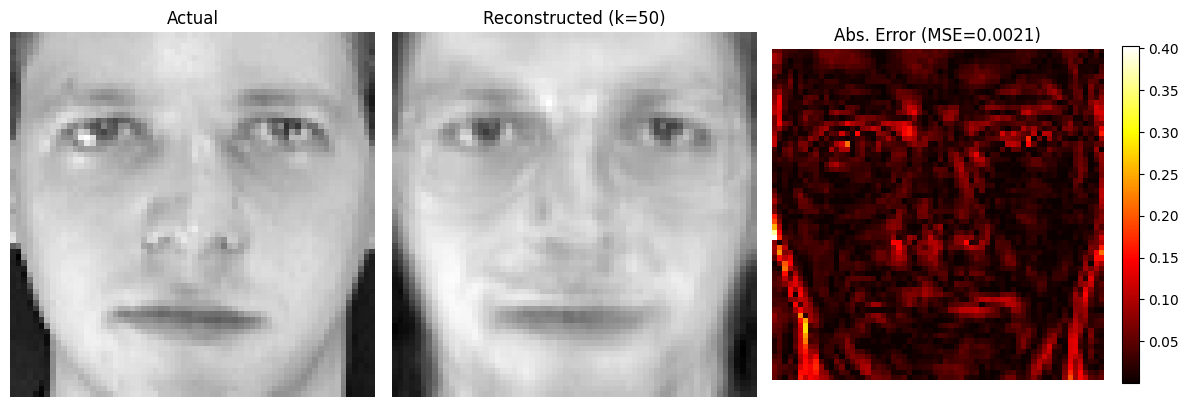

In [151]:
def plot_reconstruction_comparison(sample_idx, k, x_train, x_train_centered, eigenvectors, mean_face):
    original = x_train[sample_idx]
    face_centered = x_train_centered[sample_idx]
    reconstructed = reconstruct(face_centered, eigenvectors, k, mean_face)

    error_map = np.abs(original - reconstructed)
    mse = np.mean((original - reconstructed) ** 2)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(original.reshape(64, 64), cmap='gray')
    axes[0].set_title('Actual')
    axes[0].axis('off')

    axes[1].imshow(reconstructed.reshape(64, 64), cmap='gray')
    axes[1].set_title(f'Reconstructed (k={k})')
    axes[1].axis('off')

    im = axes[2].imshow(error_map.reshape(64, 64), cmap='hot')
    axes[2].set_title(f'Abs. Error (MSE={mse:.4f})')
    axes[2].axis('off')
    fig.colorbar(im, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

plot_reconstruction_comparison(0, 50, x_train, x_train_centered, eigenvectors, mean_face)

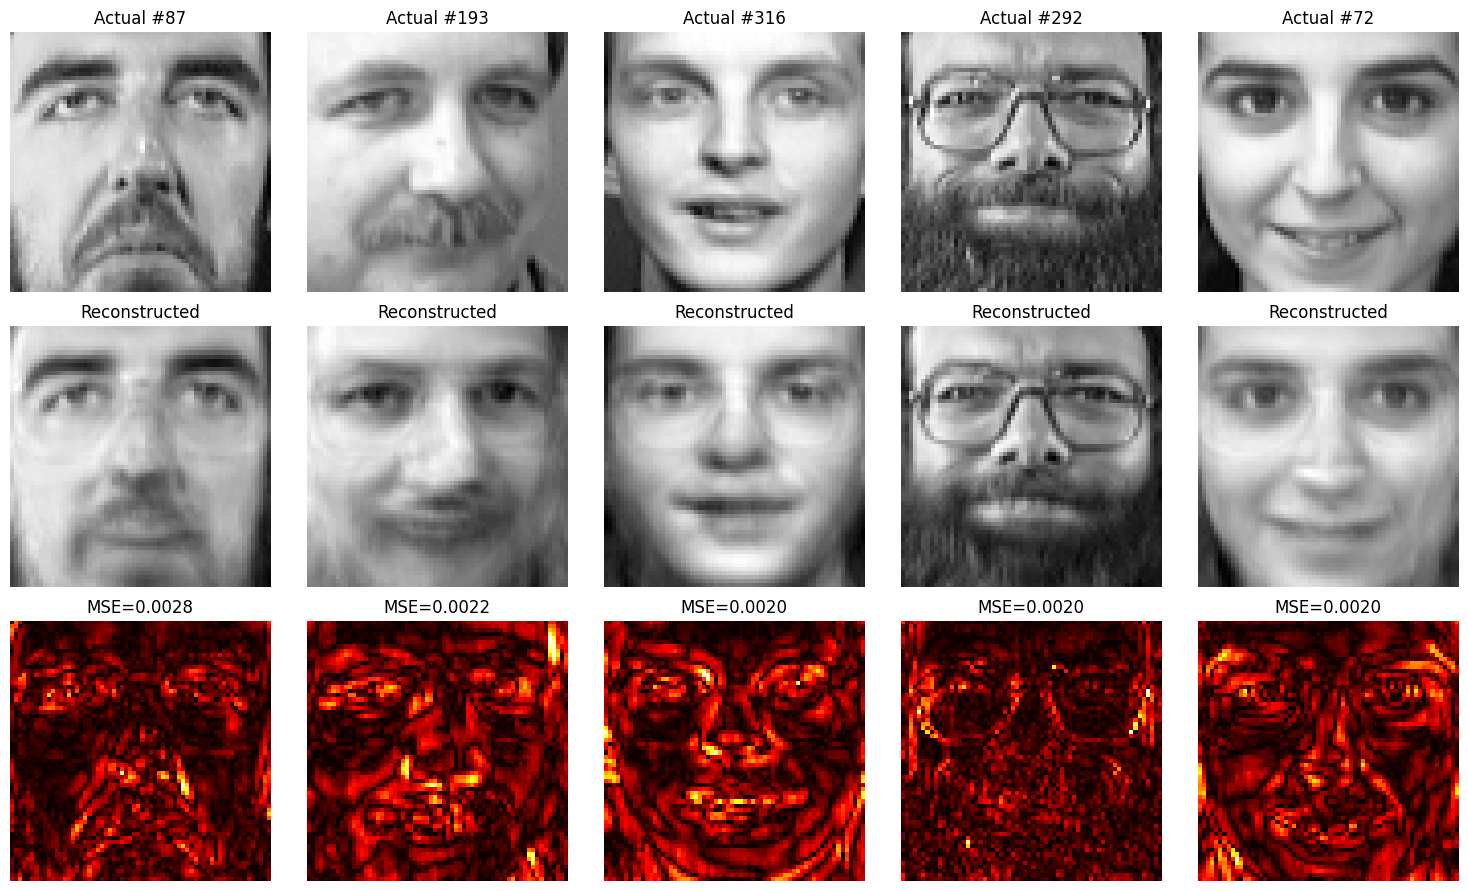

In [153]:
k = 50
n_samples = 5
sample_indices = np.random.choice(x_train.shape[0], size=n_samples, replace=False)

fig, axes = plt.subplots(3, n_samples, figsize=(3*n_samples, 9))

for col, idx in enumerate(sample_indices):
    original = x_train[idx]
    reconstructed = reconstruct(x_train_centered[idx], eigenvectors, k, mean_face)
    error_map = np.abs(original - reconstructed)
    mse = np.mean((original - reconstructed) ** 2)

    axes[0, col].imshow(original.reshape(64, 64), cmap='gray')
    axes[0, col].set_title(f'Actual #{idx}')
    axes[0, col].axis('off')

    axes[1, col].imshow(reconstructed.reshape(64, 64), cmap='gray')
    axes[1, col].set_title('Reconstructed')
    axes[1, col].axis('off')

    axes[2, col].imshow(error_map.reshape(64, 64), cmap='hot')
    axes[2, col].set_title(f'MSE={mse:.4f}')
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()

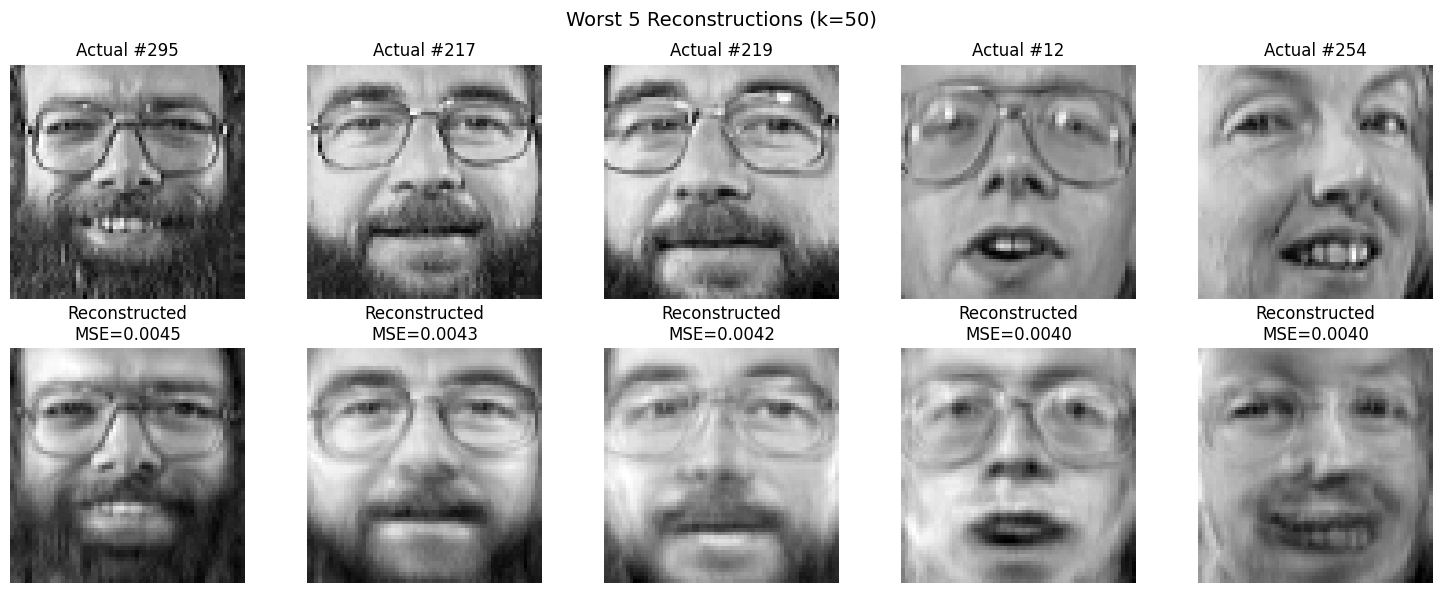

In [155]:
mean_face = np.mean(x_train, axis=0)
k = 50  # adjust as needed

def reconstruct(face_centered, eigenvectors, k, mean_face):
    top_k_vecs = eigenvectors[:, :k]
    weights = face_centered @ top_k_vecs
    return weights @ top_k_vecs.T + mean_face

# 1. Compute MSE for every training sample
mse_list = []
for i in range(x_train.shape[0]):
    reconstructed = reconstruct(x_train_centered[i], eigenvectors, k, mean_face)
    mse = np.mean((x_train[i] - reconstructed) ** 2)
    mse_list.append(mse)

mse_array = np.array(mse_list)

# 2. Find the worst-reconstructed faces (highest MSE = "most wrong")
n_worst = 5
worst_indices = np.argsort(mse_array)[::-1][:n_worst]  # descending, top n

# 3. Plot actual vs reconstructed for those worst cases
fig, axes = plt.subplots(2, n_worst, figsize=(3*n_worst, 6))

for col, idx in enumerate(worst_indices):
    reconstructed = reconstruct(x_train_centered[idx], eigenvectors, k, mean_face)

    axes[0, col].imshow(x_train[idx].reshape(64, 64), cmap='gray')
    axes[0, col].set_title(f'Actual #{idx}')
    axes[0, col].axis('off')

    axes[1, col].imshow(reconstructed.reshape(64, 64), cmap='gray')
    axes[1, col].set_title(f'Reconstructed\nMSE={mse_array[idx]:.4f}')
    axes[1, col].axis('off')

plt.suptitle(f'Worst {n_worst} Reconstructions (k={k})', fontsize=14)
plt.tight_layout()
plt.show()

In [157]:
mean_face = np.mean(x_train, axis=0)  # mean computed from TRAIN only
k = 50  # adjust as needed

def reconstruct(face_centered, eigenvectors, k, mean_face):
    top_k_vecs = eigenvectors[:, :k]
    weights = face_centered @ top_k_vecs
    return weights @ top_k_vecs.T + mean_face

# 1. Center test data using TRAIN mean (important — don't recompute mean from test)
x_test_centered = x_test - mean_face

# 2. Reconstruct every test sample
reconstructed_test = np.array([
    reconstruct(x_test_centered[i], eigenvectors, k, mean_face)
    for i in range(x_test.shape[0])
])

# 3. MSE per sample, and overall average MSE
mse_per_sample = np.mean((x_test - reconstructed_test) ** 2, axis=1)
overall_mse = np.mean(mse_per_sample)
print(f"Overall Test MSE (k={k}): {overall_mse:.4f}")

Overall Test MSE (k=50): 0.0037


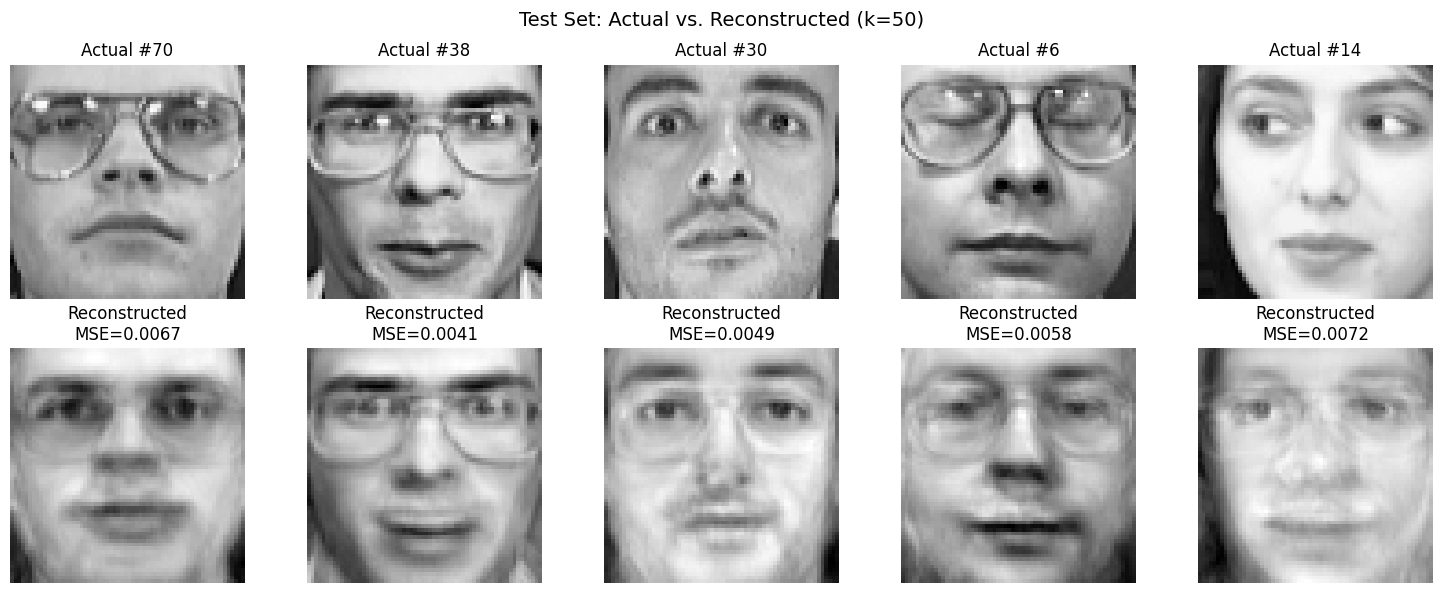

In [159]:
n_samples = 5
sample_indices = np.random.choice(x_test.shape[0], size=n_samples, replace=False)

fig, axes = plt.subplots(2, n_samples, figsize=(3*n_samples, 6))

for col, idx in enumerate(sample_indices):
    axes[0, col].imshow(x_test[idx].reshape(64, 64), cmap='gray')
    axes[0, col].set_title(f'Actual #{idx}')
    axes[0, col].axis('off')

    axes[1, col].imshow(reconstructed_test[idx].reshape(64, 64), cmap='gray')
    axes[1, col].set_title(f'Reconstructed\nMSE={mse_per_sample[idx]:.4f}')
    axes[1, col].axis('off')

plt.suptitle(f'Test Set: Actual vs. Reconstructed (k={k})', fontsize=14)
plt.tight_layout()
plt.show()

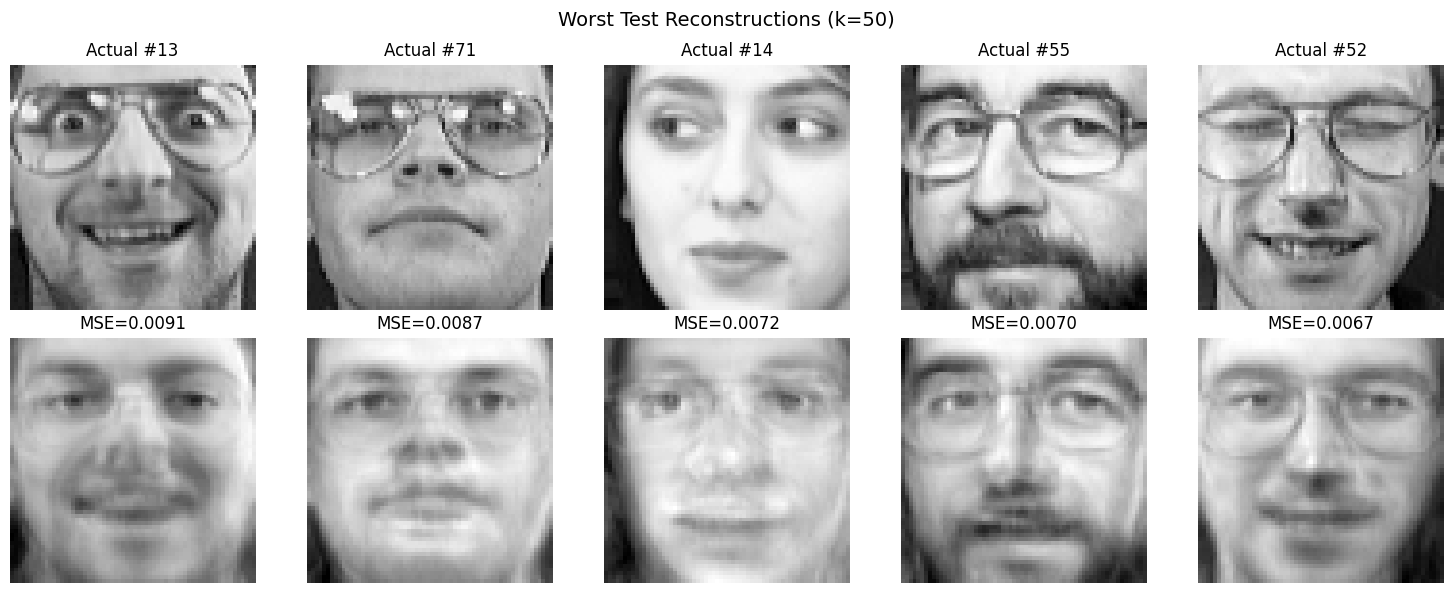

In [161]:
n_worst = 5
worst_test_indices = np.argsort(mse_per_sample)[::-1][:n_worst]

fig, axes = plt.subplots(2, n_worst, figsize=(3*n_worst, 6))
for col, idx in enumerate(worst_test_indices):
    axes[0, col].imshow(x_test[idx].reshape(64, 64), cmap='gray')
    axes[0, col].set_title(f'Actual #{idx}')
    axes[0, col].axis('off')

    axes[1, col].imshow(reconstructed_test[idx].reshape(64, 64), cmap='gray')
    axes[1, col].set_title(f'MSE={mse_per_sample[idx]:.4f}')
    axes[1, col].axis('off')

plt.suptitle(f'Worst Test Reconstructions (k={k})', fontsize=14)
plt.tight_layout()
plt.show()